## DF feature selezionate

#### Import

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os 
import sklearn.model_selection as skl_msel
import sklearn.metrics as skl_metr
import sklearn.linear_model as skl_line
import sklearn.neural_network as skl_neur
import sklearn.tree as skl_tree

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    make_scorer
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

%matplotlib inline

In [71]:
data_dir = os.path.join("..", "data")
df_select = pd.read_parquet(os.path.join(data_dir,'df_def.parquet'))

In [72]:
# variabili selezionate dal codice precedente
# è già stata esclusa 'weather description' per ragioni spiegate in precedenza

list_var = ['pressure_msl_max',
            'relative_humidity_2m_min',
            'precipitation_sum',
            'cloud_cover_min',
            'dew_point_2m_max',
            'temperature_2m_max',
            'soil_moisture_28_to_100cm_mean',
            'soil_moisture_0_to_7cm_mean',
            'soil_temperature_0_to_7cm_mean',
            'wind_speed_10m_mean',
            'wind_speed_10m_min',
            'wind_gusts_10m_max',
            'wind_direction_10m_dominant',
            'shortwave_radiation_sum',
            'sunset_minutes',
            'et0_fao_evapotranspiration'
 ]

#### Split test train

In [73]:
# split direttamente sul dataframe
xtr, xte, ytr, yte = skl_msel.train_test_split(
    df_select,
    df_select['target_pm10'],
    test_size=0.25,
    random_state=33
)

# flag basati sull'index
df_select['flag train'] = df_select.index.isin(xtr.index)
df_select['flag test'] = df_select.index.isin(xte.index)

## Modello di benchmark : Decision Tree con tutte le variabili selezionate

### Decision Tree Classifier

In [74]:
cla_tree = skl_tree.DecisionTreeClassifier(random_state=42, max_depth=3,class_weight='balanced')
cla_tree.fit(df_select.loc[df_select['flag train'], list_var].values,
             df_select.loc[df_select['flag train'], 'target_pm10'].values)

df_select['prediction (decision tree)'] = cla_tree.predict(df_select.loc[:, list_var].values)

## Modelli alternativi con tutte le variabili selezionate

### Logistic Regression

In [75]:
cla_line = skl_line.LogisticRegression(random_state=42)                    # inizializzo il modello
cla_line.fit(df_select.loc[df_select['flag train'], list_var].values,         # training del modello, sui KPIs selezionati ...
             df_select.loc[df_select['flag train'], 'target_pm10'].values)    # ... e con le varietà di iris come obiettivo

df_select['prediction (cost minimization)'] = cla_line.predict(df_select[list_var].values)  # inseriamo le predizioni in una nuova colonna

c:\Users\Boom\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Neural network RELU multilayer perceptron

In [76]:
cla_neur = skl_neur.MLPClassifier(hidden_layer_sizes=(10,4,6), max_iter=500, random_state=42)  # hidden_layer_sizes=(10,10,10), max_iter=10000
cla_neur.fit(df_select.loc[df_select['flag train'], list_var].values,
             df_select.loc[df_select['flag train'], 'target_pm10'].values)

df_select['prediction (neural network)'] = cla_neur.predict(df_select.loc[:, list_var].values)

### Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

cla_rf_bm = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf_bm.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (rf)'] = cla_rf_bm.predict(
    df_select.loc[:, list_var].values
)

### XGBoost

In [78]:
from xgboost import XGBClassifier

# calcolo peso per class imbalance
n_neg = (df_select['target_pm10'] == 0).sum()
n_pos = (df_select['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb_bm = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # 🔥 fondamentale
#    eval_metric='logloss',
    random_state=42
)

cla_xgb_bm.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (xgb)'] = cla_xgb_bm.predict(
    df_select.loc[:, list_var].values
)

df_select['proba_xgb'] = cla_xgb_bm.predict_proba(
    df_select.loc[:, list_var].values
)[:, 1]

### Confronto tra i modelli

#### Confusion Matrix

In [79]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (decision tree)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (decision tree),0,1
target_pm10,,
0,358,141
1,3,20


In [80]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (cost minimization)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (cost minimization),0,1
target_pm10,,
0,497,2
1,21,2


In [81]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (neural network)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (neural network),0,1
target_pm10,,
0,495,4
1,21,2


In [82]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,447,52
1,4,19


In [83]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,487,12
1,5,18


In [84]:
import sklearn.metrics as skl_metr

df_test = df_select.loc[df_select['flag test']]

y_true = df_test['target_pm10']

models = {
    "decision tree": "prediction (decision tree)",
    "logistic": "prediction (cost minimization)",
    "neural network": "prediction (neural network)",
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results_benchmark = pd.DataFrame(results)

df_results_benchmark = df_results_benchmark.round(4)
df_results_benchmark

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,decision tree,0.7241,0.1242,0.8696,0.2174,0.2608
1,logistic,0.9559,0.5000,0.0870,0.1481,0.1952
2,neural network,0.9521,0.3333,0.0870,0.1379,0.1520
3,rf,0.8927,0.2676,0.8261,0.4043,0.4322
4,xgb,0.9674,0.6000,0.7826,0.6792,0.6689


Considerando che l'Accuracy non è un indicatore ottimale per il nostro modello, avendo una sproporzione evidente tra 1 e 0 nella target, confrontiamo la recall in primis e poi la precision:
+ Il modello di benchmark Decision Tree performa bene per quanto riguarda la recall, con un indice di 0.76, ma con una bassa precision
+ Il modello di regressione logistica e il modello di Neural Network li escludiamo dalle possibili scelte
+ Complessivamente il modello di Random Forest e XGBoost sono quelli che performano meglio, quindi consideriamo queste due scelte per le analisi future

## Modello Full con tutte le variabili

In [85]:
# tutte le variabili presenti nel dataset

list_var_full = [
 'temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'apparent_temperature_mean',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'daylight_duration',
 'sunshine_duration',
 'precipitation_sum',
 'precipitation_hours',
 'cloud_cover_mean',
 'cloud_cover_max',
 'cloud_cover_min',
 'dew_point_2m_mean',
 'dew_point_2m_max',
 'dew_point_2m_min',
 'wet_bulb_temperature_2m_mean',
 'wet_bulb_temperature_2m_max',
 'wet_bulb_temperature_2m_min',
 'vapour_pressure_deficit_max',
 'soil_moisture_0_to_7cm_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_moisture_28_to_100cm_mean',
 'soil_moisture_7_to_28cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'soil_temperature_0_to_7cm_mean',
 'soil_temperature_28_to_100cm_mean',
 'soil_temperature_7_to_28cm_mean',
 'relative_humidity_2m_mean',
 'relative_humidity_2m_max',
 'pressure_msl_mean',
 'relative_humidity_2m_min',
 'pressure_msl_max',
 'pressure_msl_min',
 'surface_pressure_mean',
 'surface_pressure_max',
 'surface_pressure_min',
 'wind_gusts_10m_mean',
 'wind_speed_10m_mean',
 'wind_gusts_10m_min',
 'wind_speed_10m_min']

### Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier

cla_rf_full = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf_full.fit(
    df_select.loc[df_select['flag train'], list_var_full].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (rf)'] = cla_rf_full.predict(
    df_select.loc[:, list_var_full].values
)

### XGBoost

In [87]:

# calcolo peso per class imbalance
n_neg = (df_select['target_pm10'] == 0).sum()
n_pos = (df_select['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb_full = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  
#    eval_metric='logloss',
    random_state=42
)

cla_xgb_full.fit(
    df_select.loc[df_select['flag train'], list_var_full].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (xgb)'] = cla_xgb_full.predict(
    df_select.loc[:, list_var_full].values
)

df_select['proba_xgb'] = cla_xgb_full.predict_proba(
    df_select.loc[:, list_var_full].values
)[:, 1]

### Confronto tra i modelli

#### Confusion Matrix

In [88]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,462,37
1,4,19


In [89]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,487,12
1,5,18


### Scelta del modello full

In [90]:

df_test = df_select.loc[df_select['flag test']]

y_true = df_test['target_pm10']

models = {
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results_full = pd.DataFrame(results)

df_results_full = df_results_full.round(4)
df_results_full

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.9215,0.3393,0.8261,0.4810,0.4987
1,xgb,0.9674,0.6000,0.7826,0.6792,0.6689


Confronto con il modello benchmark

In [91]:
df_results_benchmark

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,decision tree,0.7241,0.1242,0.8696,0.2174,0.2608
1,logistic,0.9559,0.5000,0.0870,0.1481,0.1952
2,neural network,0.9521,0.3333,0.0870,0.1379,0.1520
3,rf,0.8927,0.2676,0.8261,0.4043,0.4322
4,xgb,0.9674,0.6000,0.7826,0.6792,0.6689


### Feature selection

### Feature Importance

#### Info

Cosa fare ora: parto dal modello di benchmark

+ Mi concentro su RF e XGBoost

+ compara le importance dei modello full e benchmarck e guarda se hai buttato via le variabili giuste
+ interazioni: aggiungi variabili di interazione tipo soil_moisture e wind
+ shap values per capire meglio la feature importance e le direzioni date dalle variabili

+ Provo altri modelli di reti neurali visti prima e cerco di capire come sono
+ Cambio gli iper parametri: vogliamo aumentare la precisione e le altre misure di performance tenendo alti accuracy e recall
+ Introduco la Cross Validation e fine-tuning

#### Feature importance Benchmark

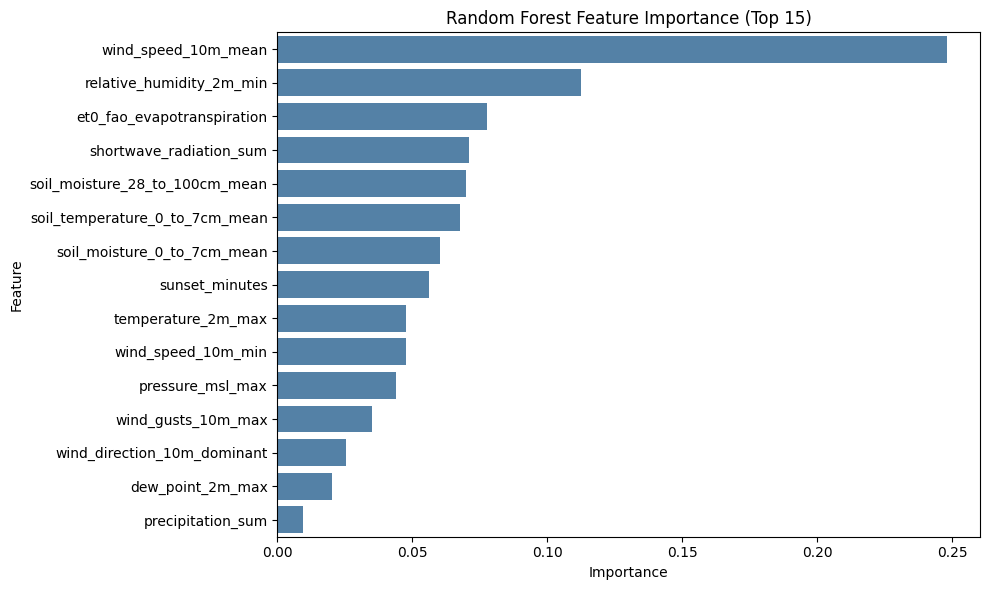

In [92]:
# importance dal modello rf di benchmark
importances = cla_rf_bm.feature_importances_

# dataframe ordinato
imp_df = pd.Series(importances, index=list_var).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=imp_df.head(15).values,
    y=imp_df.head(15).index,
    color="steelblue"
)

plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

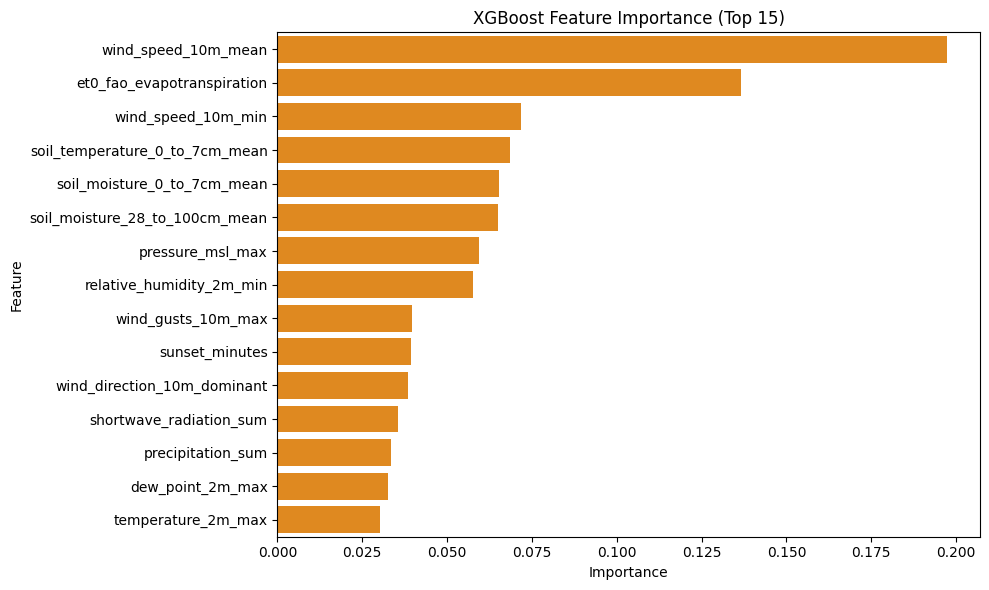

In [93]:
# importance dal modello XGBoost di bm
importances = cla_xgb_bm.feature_importances_

imp_df = pd.Series(importances, index=list_var).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=imp_df.head(15).values,
    y=imp_df.head(15).index,
    color="darkorange"
)

plt.title("XGBoost Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Feature importance Full

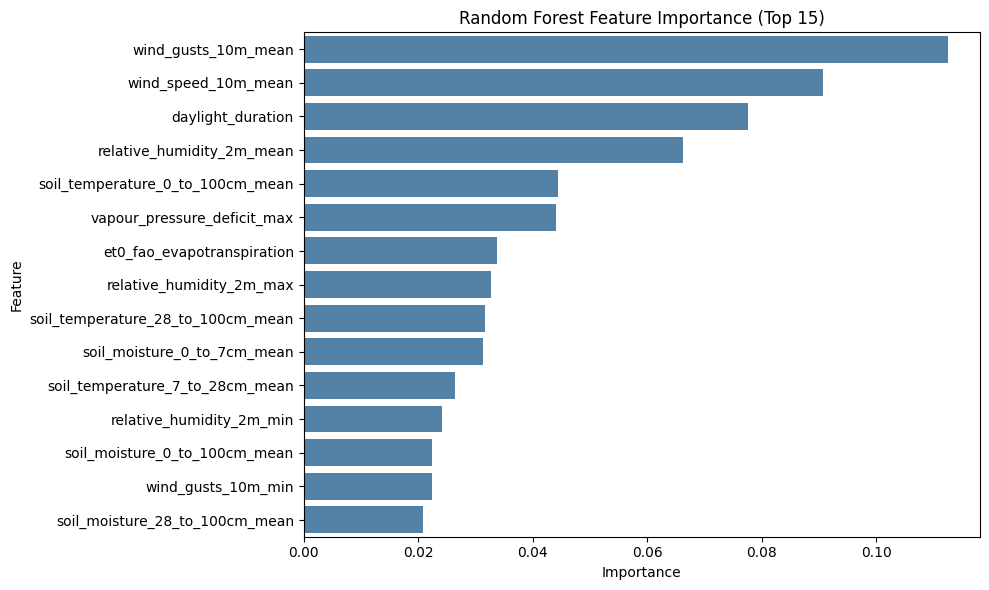

In [94]:
# importance dal modello rf full
importances = cla_rf_full.feature_importances_

# dataframe ordinato
imp_df = pd.Series(importances, index=list_var_full).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=imp_df.head(15).values,
    y=imp_df.head(15).index,
    color="steelblue"
)

plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

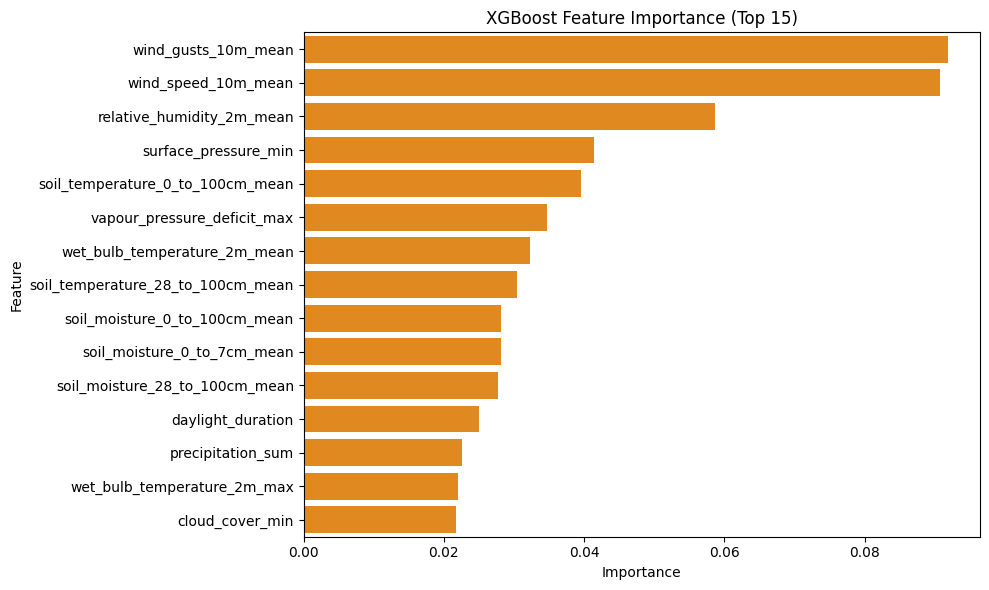

In [95]:
# importance dal modello XGBoost full
importances = cla_xgb_full.feature_importances_

imp_df = pd.Series(importances, index=list_var_full).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=imp_df.head(15).values,
    y=imp_df.head(15).index,
    color="darkorange"
)

plt.title("XGBoost Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Shap values

#### Info

Anche con gli shap values cerco di capire le features più importanti e le riaggiungo al modello
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

Shap value: quanto ogni variabile ha contribuito a spostare la previsione del modello rispetto alla media

SHAP positivo → aumenta la predizione
SHAP negativo → la diminuisce
Valore assoluto → importanza

Importanza globale delle variabili

Per ogni variabile:
prende il valore SHAP di ogni riga
fa la media del valore assoluto

#### Shap Benchmark 

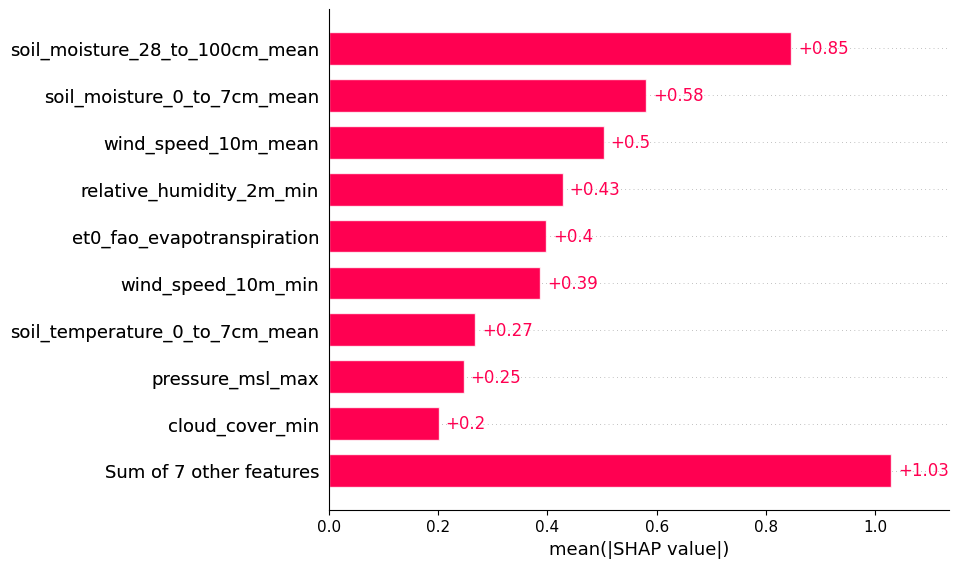

In [96]:
modello = cla_xgb_bm.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

# feature matrix e target
X = df_select[list_var]
y = df_select["target_pm10"]

# background (campione del dataset)
background = X.sample(100, random_state=42)

# SHAP explainer
explainer = shap.Explainer(modello, background)

# calcolo valori SHAP
shap_values = explainer(X)

# plot importanza globale
shap.plots.bar(shap_values)

#### Shap Full

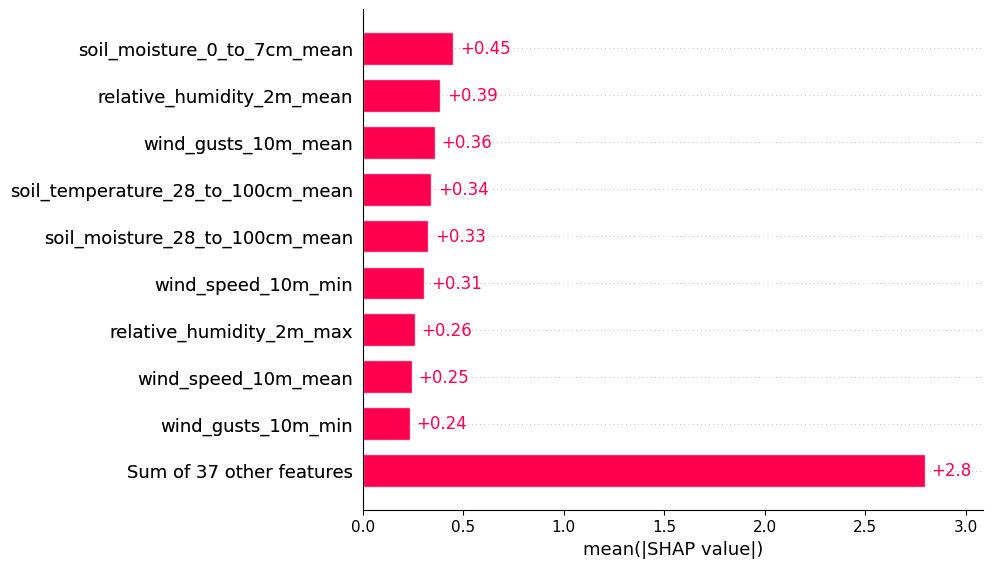

In [97]:
# train XGBoost model
modello = cla_xgb_full.fit(
    df_select.loc[df_select['flag train'], list_var_full].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)


# feature matrix e target
X = df_select[list_var_full]
y = df_select["target_pm10"]

# background (campione del dataset)
background = X.sample(100, random_state=42)

# SHAP explainer
explainer = shap.Explainer(modello, background)

# calcolo valori SHAP
shap_values = explainer(X)

# plot importanza globale
shap.plots.bar(shap_values)

### Confronto e selezione feature

In [98]:
list_var_full

['temperature_2m_mean',
 'temperature_2m_max',
 'temperature_2m_min',
 'apparent_temperature_mean',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'daylight_duration',
 'sunshine_duration',
 'precipitation_sum',
 'precipitation_hours',
 'cloud_cover_mean',
 'cloud_cover_max',
 'cloud_cover_min',
 'dew_point_2m_mean',
 'dew_point_2m_max',
 'dew_point_2m_min',
 'wet_bulb_temperature_2m_mean',
 'wet_bulb_temperature_2m_max',
 'wet_bulb_temperature_2m_min',
 'vapour_pressure_deficit_max',
 'soil_moisture_0_to_7cm_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_moisture_28_to_100cm_mean',
 'soil_moisture_7_to_28cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'soil_temperature_0_to_7cm_mean',
 'soil_temperature_28_to_100cm_mean',
 'soil_temperature_7_to_28cm_mean',
 'relative_humidity_2m_mean',
 'relative_humidity_2m_max',
 'pressure_msl_mean',


In [99]:
# rf full feature importance

'''wind_gusts_10m_mean               0.103952 non c'è: max
wind_speed_10m_mean                  0.076868 c'è
relative_humidity_2m_mean            0.064239 non c'è; c'è _min
et0_fao_evapotranspiration           0.051282 c'è
soil_temperature_0_to_100cm_mean     0.043435 non c'è: c'è 0 to 7cm
shortwave_radiation_sum              0.039862 c'è
soil_temperature_7_to_28cm_mean      0.038587 non c'è: c'è 0 to 7cm
relative_humidity_2m_min             0.038329 c'è
apparent_temperature_max             0.036698 non c'è
sunrise_minutes                      0.034064 non c'è: sunset e shortwave
daylight_duration                    0.031012 non c'è: sunset e shortwave
wind_gusts_10m_min                   0.030861 non c'è: _mean
soil_temperature_28_to_100cm_mean    0.029912 non c'è: c'è 0 to 7cm
soil_temperature_0_to_7cm_mean       0.028091 c'è
vapour_pressure_deficit_max          0.024286 non c'è
soil_moisture_7_to_28cm_mean         0.024137 non c'è: 20 to 100 e 0 to 7
soil_moisture_0_to_7cm_mean          0.024112 c'è
'''

"wind_gusts_10m_mean               0.103952 non c'è: max\nwind_speed_10m_mean                  0.076868 c'è\nrelative_humidity_2m_mean            0.064239 non c'è; c'è _min\net0_fao_evapotranspiration           0.051282 c'è\nsoil_temperature_0_to_100cm_mean     0.043435 non c'è: c'è 0 to 7cm\nshortwave_radiation_sum              0.039862 c'è\nsoil_temperature_7_to_28cm_mean      0.038587 non c'è: c'è 0 to 7cm\nrelative_humidity_2m_min             0.038329 c'è\napparent_temperature_max             0.036698 non c'è\nsunrise_minutes                      0.034064 non c'è: sunset e shortwave\ndaylight_duration                    0.031012 non c'è: sunset e shortwave\nwind_gusts_10m_min                   0.030861 non c'è: _mean\nsoil_temperature_28_to_100cm_mean    0.029912 non c'è: c'è 0 to 7cm\nsoil_temperature_0_to_7cm_mean       0.028091 c'è\nvapour_pressure_deficit_max          0.024286 non c'è\nsoil_moisture_7_to_28cm_mean         0.024137 non c'è: 20 to 100 e 0 to 7\nsoil_moisture_0_to

In [100]:
# xgb full feature importance

'''wind_gusts_10m_mean               0.111041 c'è
relative_humidity_2m_mean            0.066443 non c'è: mean
dew_point_2m_max                     0.050249 c'è
wind_speed_10m_mean                  0.049512 c'è
soil_temperature_28_to_100cm_mean    0.042097 non c'è: c'è 0 to 7cm
soil_temperature_0_to_100cm_mean     0.036269 non c'è: c'è 0 to 7cm
soil_moisture_0_to_7cm_mean          0.036127 c'è
surface_pressure_mean                0.032252 non c'è
soil_temperature_7_to_28cm_mean      0.030332 non c'è: c'è 0 to 7cm
cloud_cover_max                      0.025192 non c'è: _mean
daylight_duration                    0.022724 non c'è: sunset e shortwave
sunset_minutes                       0.021906 c'è
sunshine_duration                    0.021146 non c'è: sunset e shortwave
surface_pressure_max                 0.021067 non c'è
pressure_msl_min                     0.020180 non c'è: c'è _max
'''

"wind_gusts_10m_mean               0.111041 c'è\nrelative_humidity_2m_mean            0.066443 non c'è: mean\ndew_point_2m_max                     0.050249 c'è\nwind_speed_10m_mean                  0.049512 c'è\nsoil_temperature_28_to_100cm_mean    0.042097 non c'è: c'è 0 to 7cm\nsoil_temperature_0_to_100cm_mean     0.036269 non c'è: c'è 0 to 7cm\nsoil_moisture_0_to_7cm_mean          0.036127 c'è\nsurface_pressure_mean                0.032252 non c'è\nsoil_temperature_7_to_28cm_mean      0.030332 non c'è: c'è 0 to 7cm\ncloud_cover_max                      0.025192 non c'è: _mean\ndaylight_duration                    0.022724 non c'è: sunset e shortwave\nsunset_minutes                       0.021906 c'è\nsunshine_duration                    0.021146 non c'è: sunset e shortwave\nsurface_pressure_max                 0.021067 non c'è\npressure_msl_min                     0.020180 non c'è: c'è _max\n"

In [101]:
# xgb shap value

'''                           feature  importance
33        soil_moisture_0_to_7cm_mean    0.493440 c'è
40                wind_gusts_10m_mean    0.425778 c'è
31  soil_temperature_28_to_100cm_mean    0.391332 non c'è
35     soil_moisture_28_to_100cm_mean    0.378058 c'è
39                 wind_speed_10m_min    0.313216 non c'è
14                   cloud_cover_mean    0.286592 c'è
32   soil_temperature_0_to_100cm_mean    0.284421 non c'è
0           relative_humidity_2m_mean    0.270969 non c'è
42                 wind_gusts_10m_min    0.216374 non c'è: max
34       soil_moisture_7_to_28cm_mean    0.169403 non c'è
1            relative_humidity_2m_max    0.165644 non c'è
'''

"                           feature  importance\n33        soil_moisture_0_to_7cm_mean    0.493440 c'è\n40                wind_gusts_10m_mean    0.425778 c'è\n31  soil_temperature_28_to_100cm_mean    0.391332 non c'è\n35     soil_moisture_28_to_100cm_mean    0.378058 c'è\n39                 wind_speed_10m_min    0.313216 non c'è\n14                   cloud_cover_mean    0.286592 c'è\n32   soil_temperature_0_to_100cm_mean    0.284421 non c'è\n0           relative_humidity_2m_mean    0.270969 non c'è\n42                 wind_gusts_10m_min    0.216374 non c'è: max\n34       soil_moisture_7_to_28cm_mean    0.169403 non c'è\n1            relative_humidity_2m_max    0.165644 non c'è\n"

Aggiungo alcune variabili di interazione guardando il v-score fatto in precedenza e vedo se il modello migliora

Ricordati che comunque ci sta prediligere un modello più semplice a parità di performance: per mantenere un modello complesso servirebbero più variabili e se utilizzato per una mole di dati molto grande potrebbe essere computazionalmente costoso. In più spiegare le features più importanti se già selezionate per tipo risulta essere più chiaro se ci sono tante variabili molto correlate.

In [102]:
# aggiungo alcune variabili che mi sembrano importanti in questi modelli
upd = ['wind_gusts_10m_mean','relative_humidity_2m_mean','soil_temperature_0_to_100cm_mean','cloud_cover_max','wind_speed_10m_min']

for var in upd:
    list_var.append(var)

In [103]:
list_var

['pressure_msl_max',
 'relative_humidity_2m_min',
 'precipitation_sum',
 'cloud_cover_min',
 'dew_point_2m_max',
 'temperature_2m_max',
 'soil_moisture_28_to_100cm_mean',
 'soil_moisture_0_to_7cm_mean',
 'soil_temperature_0_to_7cm_mean',
 'wind_speed_10m_mean',
 'wind_speed_10m_min',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'sunset_minutes',
 'et0_fao_evapotranspiration',
 'wind_gusts_10m_mean',
 'relative_humidity_2m_mean',
 'soil_temperature_0_to_100cm_mean',
 'cloud_cover_max',
 'wind_speed_10m_min']

### Modelli con lista aggiornata

In [104]:
cla_rf_up = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf_up.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (rf)'] = cla_rf_up.predict(
    df_select.loc[:, list_var].values
)

In [105]:
# calcolo peso per class imbalance
n_neg = (df_select['target_pm10'] == 0).sum()
n_pos = (df_select['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb_up = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # 🔥 fondamentale
#    eval_metric='logloss',
    random_state=42
)

cla_xgb_up.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (xgb)'] = cla_xgb_up.predict(
    df_select.loc[:, list_var].values
)

df_select['proba_xgb'] = cla_xgb_up.predict_proba(
    df_select.loc[:, list_var].values
)[:, 1]

#### Confusion Matrix

In [106]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,459,40
1,4,19


In [107]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,488,11
1,5,18


In [108]:
df_test = df_select.loc[df_select['flag test']]

y_true = df_test['target_pm10']

models = {
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results_update = pd.DataFrame(results)

df_results_update = df_results_update.round(4)
df_results_update

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.9157,0.3220,0.8261,0.4634,0.4835
1,xgb,0.9693,0.6207,0.7826,0.6923,0.6814


#### Confronto

In [109]:
df_results_benchmark

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,decision tree,0.7241,0.1242,0.8696,0.2174,0.2608
1,logistic,0.9559,0.5000,0.0870,0.1481,0.1952
2,neural network,0.9521,0.3333,0.0870,0.1379,0.1520
3,rf,0.8927,0.2676,0.8261,0.4043,0.4322
4,xgb,0.9674,0.6000,0.7826,0.6792,0.6689


## Interazioni

Creo variabili di interazione tra quelle più collegate insieme: so che in questi modelli a volte non serve ma provo



In [110]:
df_select['moisture_direction'] = df_select["soil_moisture_0_to_7cm_mean"] * df_select["wind_direction_10m_dominant"]
df_select['moisture_speed'] = df_select["soil_moisture_0_to_7cm_mean"] * df_select["wind_speed_10m_mean"]


In [111]:
list_var.append('moisture_direction')
list_var.append('moisture_speed')

In [112]:
cla_rf_in = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf_in.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (rf)'] = cla_rf_in.predict(
    df_select.loc[:, list_var].values
)

In [113]:
# calcolo peso per class imbalance
n_neg = (df_select['target_pm10'] == 0).sum()
n_pos = (df_select['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb_in = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, 
#    eval_metric='logloss',
    random_state=42
)

cla_xgb_in.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (xgb)'] = cla_xgb_in.predict(
    df_select.loc[:, list_var].values
)

df_select['proba_xgb'] = cla_xgb_in.predict_proba(
    df_select.loc[:, list_var].values
)[:, 1]

#### Confusion Matrix

In [114]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,458,41
1,4,19


In [115]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,487,12
1,5,18


In [116]:
df_test = df_select.loc[df_select['flag test']]

y_true = df_test['target_pm10']

models = {
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results_interaction = pd.DataFrame(results)

df_results_interaction = df_results_interaction.round(4)
df_results_interaction

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.9138,0.3167,0.8261,0.4578,0.4787
1,xgb,0.9674,0.6000,0.7826,0.6792,0.6689


In [117]:
df_results_update

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.9157,0.3220,0.8261,0.4634,0.4835
1,xgb,0.9693,0.6207,0.7826,0.6923,0.6814


In [118]:
df_results_benchmark

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,decision tree,0.7241,0.1242,0.8696,0.2174,0.2608
1,logistic,0.9559,0.5000,0.0870,0.1481,0.1952
2,neural network,0.9521,0.3333,0.0870,0.1379,0.1520
3,rf,0.8927,0.2676,0.8261,0.4043,0.4322
4,xgb,0.9674,0.6000,0.7826,0.6792,0.6689


## Lista variabili definitiva

Dopo aver controllato al meglio le relazioni tra le variabili la lista definitiva è la seguente

In [119]:
list_var = ['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum'
                     ]

In [120]:
cla_rf = RandomForestClassifier(
    n_estimators=100,          # numero di alberi
    max_depth=5,               # puoi partire con 5–10
    random_state=42,
    class_weight='balanced',   # IMPORTANTISSIMO per il tuo dataset
)

cla_rf.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (rf)'] = cla_rf.predict(
    df_select.loc[:, list_var].values
)

In [121]:
# calcolo peso per class imbalance
n_neg = (df_select['target_pm10'] == 0).sum()
n_pos = (df_select['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

cla_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, 
#    eval_metric='logloss',
    random_state=42
)

cla_xgb.fit(
    df_select.loc[df_select['flag train'], list_var].values,
    df_select.loc[df_select['flag train'], 'target_pm10'].values
)

df_select['prediction (xgb)'] = cla_xgb.predict(
    df_select.loc[:, list_var].values
)

df_select['proba_xgb'] = cla_xgb.predict_proba(
    df_select.loc[:, list_var].values
)[:, 1]

#### Confusion Matrix

In [122]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (rf)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (rf),0,1
target_pm10,,
0,430,69
1,5,18


In [123]:
df_pivot = pd.pivot_table(df_select.loc[df_select['flag test'], :],
                          index='target_pm10', columns='prediction (xgb)',
                          values='giorno', aggfunc='count', fill_value=0)
df_pivot.style.background_gradient(vmin=0, vmax=5).format(precision=0)

prediction (xgb),0,1
target_pm10,,
0,479,20
1,5,18


In [124]:
df_test = df_select.loc[df_select['flag test']]

y_true = df_test['target_pm10']

models = {
    "rf": "prediction (rf)",
    "xgb": "prediction (xgb)"
}

results = []

for name, col in models.items():
    y_pred = df_test[col]

    results.append({
        "Model": name,
        "Accuracy": skl_metr.accuracy_score(y_true, y_pred),
        "Precision": skl_metr.precision_score(y_true, y_pred),
        "Recall": skl_metr.recall_score(y_true, y_pred),
        "F1-score": skl_metr.f1_score(y_true, y_pred),
        "MCC": skl_metr.matthews_corrcoef(y_true, y_pred)
    })

df_results = pd.DataFrame(results)

df_results = df_results.round(4)
df_results

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,rf,0.8582,0.2069,0.7826,0.3273,0.3548
1,xgb,0.9521,0.4737,0.7826,0.5902,0.5866


Entrambi i modelli sono buoni, con RF che ha un miglior valore di recall ma una bassa precision e XGBoost che ha entrmbi buoni ma non altissimi

## Fine-tuning e CV

### XGBoost

In [125]:
# split direttamente sul dataframe
xtr, xte, ytr, yte = skl_msel.train_test_split(
    df_select,
    df_select['target_pm10'],
    test_size=0.30,
    random_state=33
)

# flag basati sull'index
df_select['flag train'] = df_select.index.isin(xtr.index)
df_select['flag test'] = df_select.index.isin(xte.index)

In [126]:
recall = make_scorer(recall_score)

n_neg = (df_select['target_pm10'] == 0).sum()
n_pos = (df_select['target_pm10'] == 1).sum()
scale_pos_weight = n_neg / n_pos

param_grid = {
    "max_depth": [4, 8],
    "learning_rate": [0.03, 0.05],
    "n_estimators": [500, 700]
}

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,

)

grid = GridSearchCV(
    model,
    param_grid,
    scoring=recall, 
    cv=5,
    n_jobs=-1
)
grid.fit(
    df_select.loc[df_select['flag train'], list_var],
    df_select.loc[df_select['flag train'], 'target_pm10']
)

best_model = grid.best_estimator_

In [127]:
best_params = grid.best_params_
print(best_params)

{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 700}


In [128]:
# predizioni train
y_pred_train = (best_model.predict_proba(
    df_select.loc[df_select['flag train'], list_var]
)[:, 1] > 0.3).astype(int)

# predizioni test
y_pred_test = (best_model.predict_proba(
    df_select.loc[df_select['flag test'], list_var]
)[:, 1] > 0.3).astype(int)

y_train = df_select.loc[df_select['flag train'], 'target_pm10']
y_test = df_select.loc[df_select['flag test'], 'target_pm10']

print("TRAIN")
print("Recall:", recall_score(y_train, y_pred_train))
print("Precision:", precision_score(y_train, y_pred_train))

print("\nTEST")
print("Recall:", recall_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))

print("\nClassification report TEST")
print(classification_report(y_test, y_pred_test))

TRAIN
Recall: 1.0
Precision: 0.6559139784946236

TEST
Recall: 0.90625
Precision: 0.7073170731707317

Classification report TEST
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       595
           1       0.71      0.91      0.79        32

    accuracy                           0.98       627
   macro avg       0.85      0.94      0.89       627
weighted avg       0.98      0.98      0.98       627

